# Gradient Descent - Multiple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# generating sythetic datasets
from sklearn.datasets import make_regression
x,y = make_regression(n_samples = 1000, n_targets = 1, n_features = 3, n_informative = 3, noise = 10)

In [6]:
print(x.shape)
print(y.shape)

(1000, 3)
(1000,)


In [7]:
# converting to dataframe
df = pd.DataFrame({
    'feature1':x[:,0],
    'feature2':x[:,1],
    'target':y
})
df.head()

,feature1,feature2,target
0,-2.011799,0.014300,-70.744907
1,-3.127209,-2.373232,-89.977327
2,1.224316,-0.427957,56.474523
3,0.054281,-1.063697,72.123775
4,-1.315892,-1.369424,-106.359127


In [9]:
# plot of existing data
import plotly.express as px
fig = px.scatter_3d(df,x = 'feature1', y = 'feature2', z = 'target', color = 'target')
fig

In [11]:
# sklearn linearRegression for comparison
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [12]:
# model training
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [13]:
# predicitons
y_pred = lr.predict(x_test)

In [15]:
# evaluation
from sklearn.metrics import r2_score
r2_score_lr =  r2_score(y_test, y_pred)
r2_score_lr

0.9847766642055926

In [17]:
print(lr.coef_) # b1 - b3
print(lr.intercept_)  # b0

[43.58567106 27.10789202 49.17545269]
-0.08605208194080172


# Custom class - Batch Gradient Descent

In [25]:
class batch_gd:
  def __init__(self, learning_rate, epochs):
    self.n = learning_rate
    self.epochs = epochs
    self.intercept_ = None
    self.coef_ = None
    self.loss_list = []

  def fit(self, x_train, y_train):
    self.intercept_ = 0 # random initialization
    self.coef_ = np.ones(x_train.shape[1])
    for i in range(self.epochs):

      # updating the intercept
      y_pred = (x_train @ self.coef_) + self.intercept_
      d_intercept = (-2/x_train.shape[0]) * np.sum(y_train - y_pred)
      self.intercept_ -= (self.n * d_intercept)

      # updating the coef_
      d_coef = (-2/x_train.shape[0]) * ((y_train - y_pred)@(x_train))
      self.coef_ -= (self.n * d_coef)

      loss = np.mean((y_train - y_pred)**2)
      self.loss_list.append(loss)

      print(f'step {i} | loss = {loss}')

    print('intercept = ',self.intercept_)
    print('coefficients = ',self.coef_)


  def predict(self,x_test):
    return self.intercept_ + np.dot(x_test, self.coef_)

In [26]:
# model training
gd = batch_gd(0.01, 1000)
gd.fit(x_train, y_train)

step 0 | loss = 5191.048752639592
step 1 | loss = 4977.015242452753
step 2 | loss = 4771.981859465033
step 3 | loss = 4575.569556116772
step 4 | loss = 4387.415271399112
step 5 | loss = 4207.171255744661
step 6 | loss = 4034.504424461103
step 7 | loss = 3869.095738499675
step 8 | loss = 3710.639611401684
step 9 | loss = 3558.8433413151915
step 10 | loss = 3413.4265670209797
step 11 | loss = 3274.1207469517713
step 12 | loss = 3140.6686602317995
step 13 | loss = 3012.8239288049585
step 14 | loss = 2890.3505597592784
step 15 | loss = 2773.022506993229
step 16 | loss = 2660.6232514055596
step 17 | loss = 2552.945398825026
step 18 | loss = 2449.7902949295544
step 19 | loss = 2350.9676564361475
step 20 | loss = 2256.295217873305
step 21 | loss = 2165.5983932768318
step 22 | loss = 2078.7099521778455
step 23 | loss = 1995.4697092785032
step 24 | loss = 1915.7242272365693
step 25 | loss = 1839.3265320044384
step 26 | loss = 1766.135840191713
step 27 | loss = 1696.0172979429015
step 28 | loss 

In [29]:
y_pred_gd = gd.predict(x_test)

In [28]:
print(lr.coef_)
print(lr.intercept_)

[43.58567106 27.10789202 49.17545269]
-0.08605208194080172


In [31]:
# R2_score for GD
r2_gd = r2_score(y_test, y_pred_gd)
r2_gd

0.984776664148597

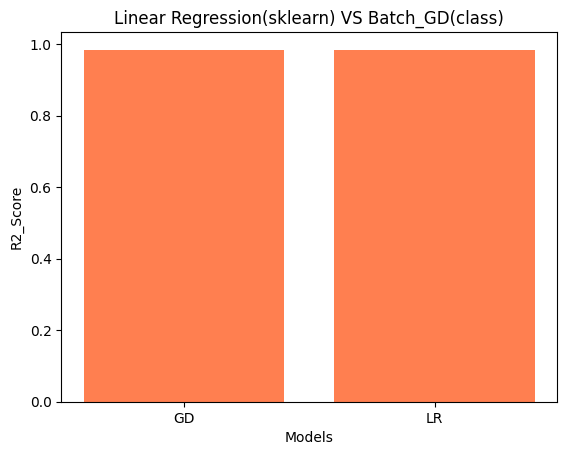

In [32]:
# bar plot for comparing both R2_Scores
data = {
    'GD':r2_gd,
    'LR':r2_score_lr
}

plt.bar(data.keys(), data.values(), color = 'coral')
plt.xlabel('Models')
plt.ylabel('R2_Score')
plt.title('Linear Regression(sklearn) VS Batch_GD(class)')
plt.show()